In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
spread = pd.read_csv("C:/Users/tprat/Downloads/T10Y2Y.csv")
recession = pd.read_csv("C:/Users/tprat/Downloads/USREC.csv")

In [5]:
spread.head()

,observation_date,T10Y2Y
0,1976-06-01,0.68
1,1976-06-02,0.71
2,1976-06-03,0.70
3,1976-06-04,0.77
4,1976-06-07,0.79


In [7]:
recession.head()

,observation_date,USREC
0,1854-11-30,1
1,1854-12-31,0
2,1855-01-31,0
3,1855-02-28,0
4,1855-03-31,0


In [15]:
#Converted data
spread['observation_date'] = pd.to_datetime(
    spread['observation_date'])

recession['observation_date'] = pd.to_datetime(
    recession['observation_date'])

In [11]:
spread.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13049 entries, 0 to 13048
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  13049 non-null  datetime64[ns]
 1   T10Y2Y            12500 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 204.0 KB


In [19]:
#Converted daily into monthly
spread_monthly = (
    spread
    .set_index('observation_date')
    .resample('MS')
    .mean()
    .reset_index())

In [21]:
spread_monthly.head()

,observation_date,T10Y2Y
0,1976-06-01,0.801364
1,1976-07-01,0.981905
2,1976-08-01,1.137273
3,1976-09-01,1.178095
4,1976-10-01,1.427000


In [23]:
#Merged Datasets
df = pd.merge(
    spread_monthly,
    recession,
    on='observation_date',
    how='inner')

In [25]:
df.shape

(600, 3)

In [27]:
df.columns

Index(['observation_date', 'T10Y2Y', 'USREC'], dtype='object')

In [29]:
df.head()

,observation_date,T10Y2Y,USREC
0,1976-06-01,0.801364,0
1,1976-07-01,0.981905,0
2,1976-08-01,1.137273,0
3,1976-09-01,1.178095,0
4,1976-10-01,1.427000,0


In [31]:
df['T10Y2Y'].describe()

count    600.000000
mean       0.847584
std        0.911465
min       -2.135714
25%        0.188382
50%        0.782013
75%        1.467921
max        2.834211
Name: T10Y2Y, dtype: float64

In [33]:
df['Inversion'] = (df['T10Y2Y'] < 0).astype(int)
inversion_rate = df['Inversion'].mean()*100
print(inversion_rate)

16.5


In [41]:
#deepest Yield Curve Inversion
df.loc[df['T10Y2Y'].idxmin()]

observation_date    1980-03-01 00:00:00
T10Y2Y                        -2.135714
USREC                                 1
Inversion                             1
Name: 45, dtype: object

In [43]:
#Steepest Yield Curve Inversion
df.loc[df['T10Y2Y'].idxmax()]

observation_date    2010-02-01 00:00:00
T10Y2Y                         2.834211
USREC                                 0
Inversion                             0
Name: 404, dtype: object

| Finding             | Result                 |
| ------------------- | ---------------------- |
| Average Spread      | 0.848%                 |
| Standard Deviation  | 0.911%                 |
| Deepest Inversion   | -2.136% (March 1980)   |
| Steepest Spread     | 2.834% (February 2010) |
| Inversion Frequency | 16.5%                  |


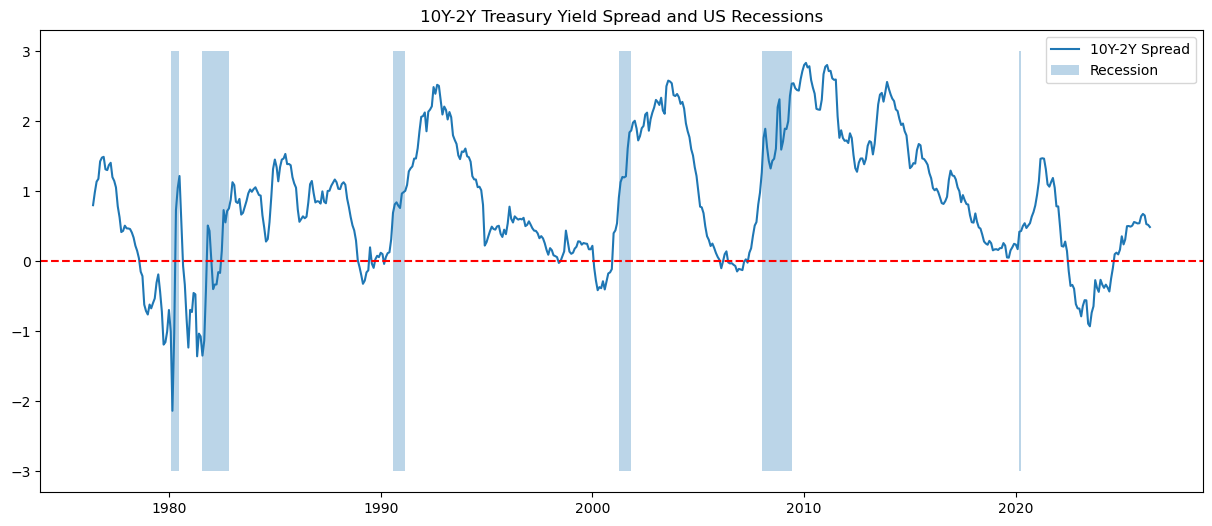

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    df['observation_date'],
    df['T10Y2Y'],
    label='10Y-2Y Spread')

plt.fill_between(
    df['observation_date'],
    -3,
    3,
    where=df['USREC']==1,
    alpha=0.3,
    label='Recession')

plt.axhline(
    y=0,
    color='red',
    linestyle='--')

plt.title('10Y-2Y Treasury Yield Spread and US Recessions')
plt.legend()
plt.show()

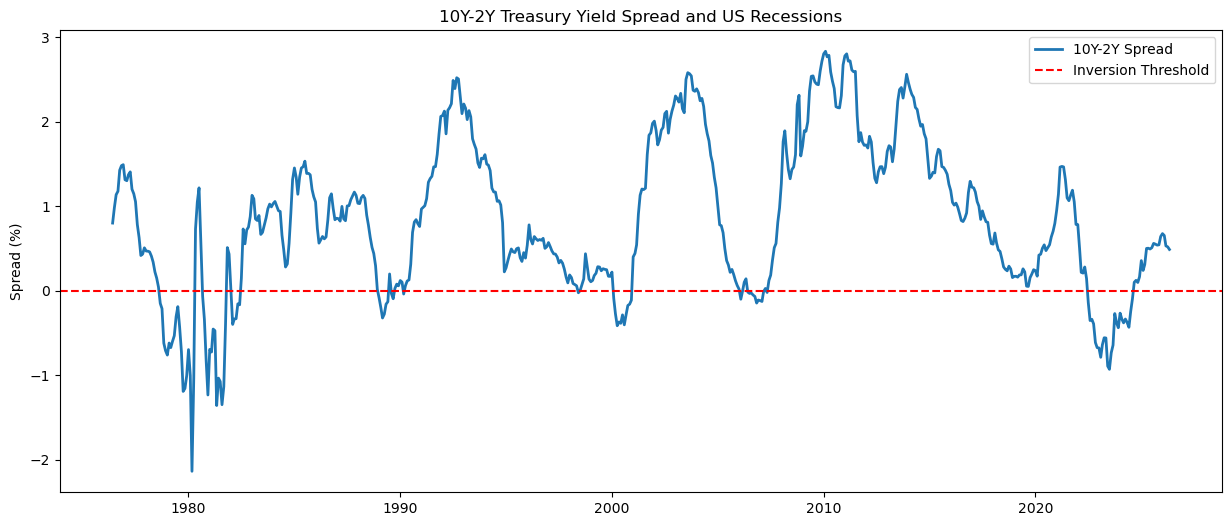

In [47]:
plt.figure(figsize=(15,6))

plt.plot(
    df['observation_date'],
    df['T10Y2Y'],
    linewidth=2,
    label='10Y-2Y Spread'
)

for i in range(len(df)):
    if df['USREC'].iloc[i] == 1:
        plt.axvspan(
            df['observation_date'].iloc[i],
            df['observation_date'].iloc[i],
            alpha=0.3
        )

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    label='Inversion Threshold'
)

plt.title('10Y-2Y Treasury Yield Spread and US Recessions')
plt.ylabel('Spread (%)')
plt.legend()
plt.show()

In [81]:
df['Future_Recession_12M'] = df['USREC'].shift(-12)
df[['T10Y2Y','Future_Recession_12M']].head()

,T10Y2Y,Future_Recession_12M
0,0.801364,0.0
1,0.981905,0.0
2,1.137273,0.0
3,1.178095,0.0
4,1.427000,0.0


In [51]:
df[['observation_date','T10Y2Y','USREC','Future_Recession_12M']].tail(15)

,observation_date,T10Y2Y,USREC,Future_Recession_12M
585,2025-03-01,0.310476,0,0.0
586,2025-04-01,0.501429,0,0.0
587,2025-05-01,0.503810,0,0.0
588,2025-06-01,0.494500,0,NaN
589,2025-07-01,0.509545,0,NaN
590,2025-08-01,0.560952,0,NaN
591,2025-09-01,0.551905,0,NaN
592,2025-10-01,0.540455,0,NaN
593,2025-11-01,0.543889,0,NaN
594,2025-12-01,0.642273,0,NaN


In [63]:
data = df.dropna().copy()

In [65]:
data.shape

(588, 5)

In [67]:
data.groupby('Future_Recession_12M')['T10Y2Y'].mean()

Future_Recession_12M
0.0    0.951141
1.0   -0.039115
Name: T10Y2Y, dtype: float64

In [69]:
#Linear Regression
from sklearn.linear_model import LogisticRegression

X = data[['T10Y2Y']]
y = data['Future_Recession_12M']

model = LogisticRegression()

model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: [-1.58523769]
Coefficient: [[-1.42861542]]


In [77]:
data[['observation_date',
      'T10Y2Y',
      'Probability']].head()

,observation_date,T10Y2Y,Probability
0,1976-06-01,0.801364,0.061222
1,1976-07-01,0.981905,0.047971
2,1976-08-01,1.137273,0.038793
3,1976-09-01,1.178095,0.036675
4,1976-10-01,1.427000,0.025986


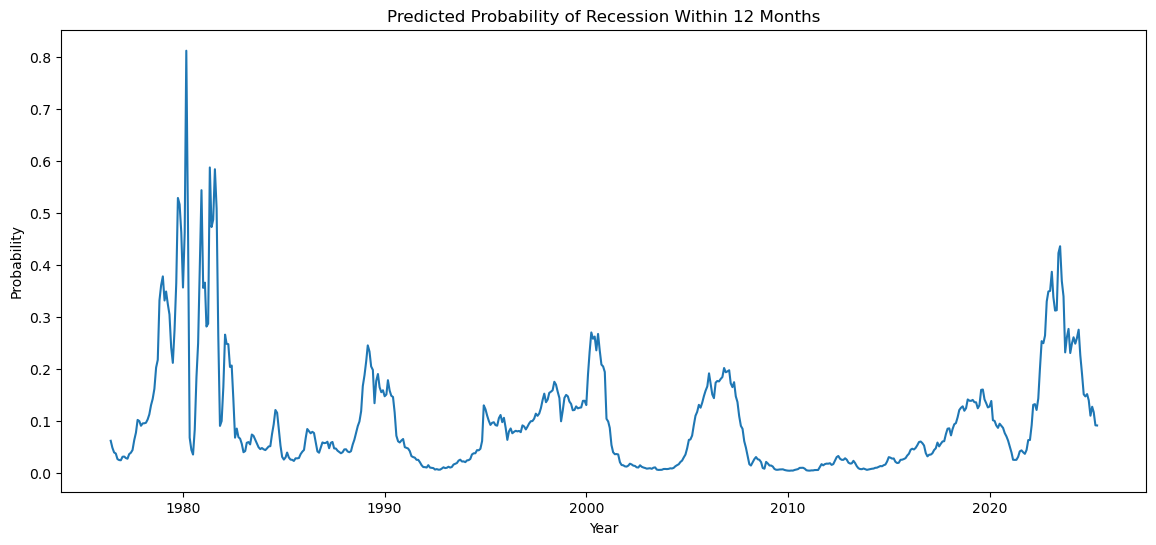

In [79]:
#Probabilty Chart
plt.figure(figsize=(14,6))

plt.plot(
    data['observation_date'],
    data['Probability']
)

plt.title(
    'Predicted Probability of Recession Within 12 Months'
)

plt.ylabel('Probability')
plt.xlabel('Year')

plt.show()

In [85]:
data['Probability'].describe()

count    588.000000
mean       0.098583
std        0.107787
min        0.003561
25%        0.024504
50%        0.061011
75%        0.136127
max        0.812430
Name: Probability, dtype: float64

In [87]:
data[['observation_date','T10Y2Y','Probability']]\
.sort_values('Probability', ascending=False)\
.head(10)

,observation_date,T10Y2Y,Probability
45,1980-03-01,-2.135714,0.812430
59,1981-05-01,-1.357500,0.587613
62,1981-08-01,-1.347619,0.584188
54,1980-12-01,-1.232727,0.543851
40,1979-10-01,-1.190455,0.528834
41,1979-11-01,-1.155263,0.516291
63,1981-09-01,-1.133810,0.508634
61,1981-07-01,-1.073182,0.486985
60,1981-06-01,-1.033636,0.472884
46,1980-04-01,-1.028571,0.471081


In [89]:
data[['observation_date','T10Y2Y','Probability']]\
.sort_values('Probability', ascending=True)\
.head(10)

,observation_date,T10Y2Y,Probability
404,2010-02-01,2.834211,0.003561
403,2010-01-01,2.804211,0.003716
416,2011-02-01,2.803684,0.003719
406,2010-04-01,2.786364,0.003812
415,2011-01-01,2.779500,0.003849
405,2010-03-01,2.768696,0.003909
418,2011-04-01,2.720500,0.004186
417,2011-03-01,2.716957,0.004207
402,2009-12-01,2.715455,0.004216
414,2010-12-01,2.672727,0.004480


In [93]:
df['Recession_Start'] = (
    (df['USREC'] == 1) &
    (df['USREC'].shift(1) == 0)
)

df[df['Recession_Start']][
    ['observation_date']
]

,observation_date
44,1980-02-01
62,1981-08-01
170,1990-08-01
298,2001-04-01
379,2008-01-01
525,2020-03-01


In [95]:
df['Inversion_Start'] = (
    (df['Inversion'] == 1) &
    (df['Inversion'].shift(1) == 0)
)

df[df['Inversion_Start']][
    ['observation_date']
]

,observation_date
27,1978-09-01
51,1980-09-01
68,1982-02-01
151,1989-01-01
158,1989-08-01
165,1990-03-01
264,1998-06-01
284,2000-02-01
356,2006-02-01
360,2006-06-01


In [97]:
recession_dates = df.loc[
    df['Recession_Start'],
    'observation_date'
].tolist()

inversion_dates = df.loc[
    df['Inversion_Start'],
    'observation_date'
].tolist()

print("Recession Starts")
print(recession_dates)

print("\nInversion Starts")
print(inversion_dates)

Recession Starts
[Timestamp('1980-02-01 00:00:00'), Timestamp('1981-08-01 00:00:00'), Timestamp('1990-08-01 00:00:00'), Timestamp('2001-04-01 00:00:00'), Timestamp('2008-01-01 00:00:00'), Timestamp('2020-03-01 00:00:00')]

Inversion Starts
[Timestamp('1978-09-01 00:00:00'), Timestamp('1980-09-01 00:00:00'), Timestamp('1982-02-01 00:00:00'), Timestamp('1989-01-01 00:00:00'), Timestamp('1989-08-01 00:00:00'), Timestamp('1990-03-01 00:00:00'), Timestamp('1998-06-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2006-02-01 00:00:00'), Timestamp('2006-06-01 00:00:00'), Timestamp('2007-05-01 00:00:00'), Timestamp('2022-07-01 00:00:00')]


In [99]:
lead_times = [17, 11, 5, 14, 8]

avg = sum(lead_times)/len(lead_times)
print(avg)

11.0
